The first cell just loads in some libraries that we'll need

In [ ]:
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)

from gerrychain.proposals import recom, propose_random_flip

from gerrychain.tree import recursive_tree_part, recursive_seed_part, bipartition_tree

from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias

from gerrychain.updaters import cut_edges

from gerrychain.tree import bipartition_tree, find_balanced_edge_cuts_memoization


import geopandas as gpd
import matplotlib.pyplot as plt

import networkx as nx
from functools import partial 

import csv
import pandas as pd

import json

import numpy as np


The next cell loads in the dual graph (.json) and geodataframe (.shp). You need both to compute the county splits efficiently. 

In [ ]:
graph = Graph.from_json("./AL_Processed_Precincts.json")
df = gpd.read_file("./AL_Processed_Precincts.shp")

ideal_population = df['TOTPOP'].sum()/9


Next up is just a plot of the current congressional map on the dual graph and on the shapefile. Not necessary, just fun!

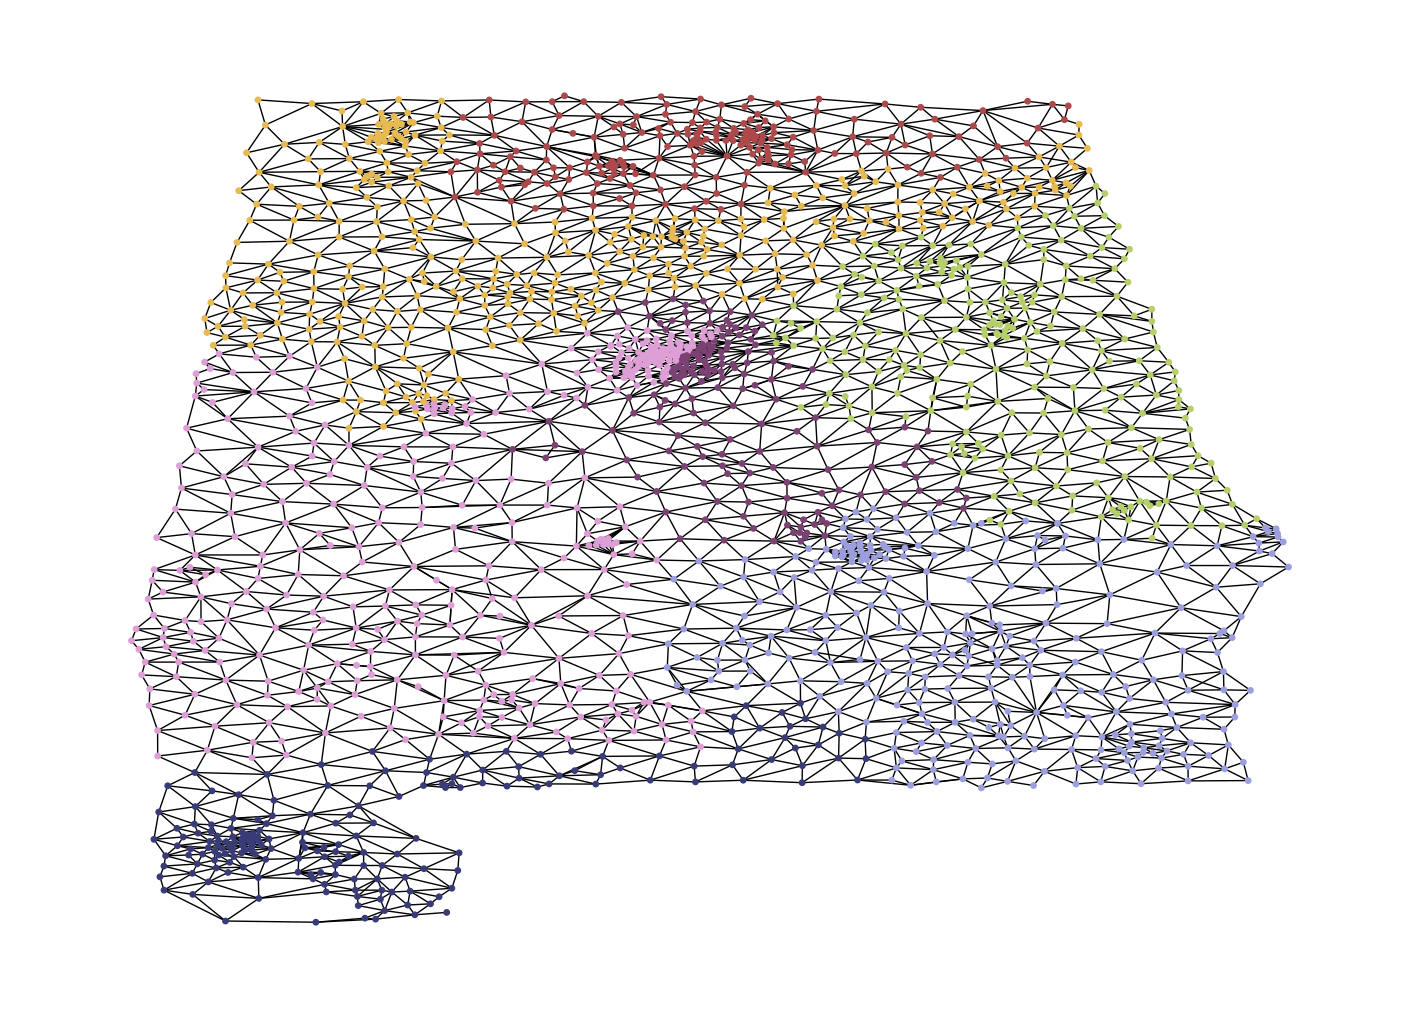

In [ ]:
plt.figure(figsize=(14,10))
nx.draw(graph, pos = {x:(graph.nodes()[x]['C_X'],graph.nodes()[x]['C_Y']) for x in graph.nodes()},node_color=[graph.nodes()[x]['CD'] for x in graph.nodes()],
        cmap='tab20b',node_size=15)
    

(np.float64(-88.65247604999999),
 np.float64(-84.70899695),
 np.float64(29.901244849999998),
 np.float64(35.251208150000004))

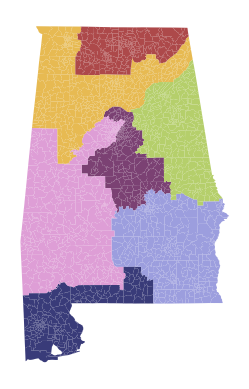

In [ ]:
df.plot(column="CD",cmap='tab20b')
plt.axis('off')


Next we create some updaters. You will likely need to update this code to account for how your dataframe is labelled in the county_splits function and to have the correct columns for elections and race data.

In [ ]:
#i added this for mmd
for node in graph.nodes():
    graph.nodes()[node]["TOTPOP"] = graph.nodes()[node]["TOTPOP"]
    graph.nodes()[node]["BLACK"] = graph.nodes()[node]["NH_BLACK"]
    graph.nodes()[node]["HISP"] = graph.nodes()[node]["HISP"]
    graph.nodes()[node]["WHITE"] = graph.nodes()[node]["NH_WHITE"]

def calc_minority_metrics(statewide_demos, demos_by_dist):
    minority_groups = ["BLACK", "HISP"]

    statewide_total = statewide_demos["TOTPOP"]
    statewide_minority_total = sum(statewide_demos[g] for g in minority_groups)

    statewide_minority_share = statewide_minority_total / statewide_total

    opportunity_districts = 0
    coalition_districts = 0

    for dist in demos_by_dist:
        total = dist["TOTPOP"]
        if total == 0:
            continue

        # Single-group opportunity (any minority > 50%)
        for g in minority_groups:
            if dist[g] / total >= 0.50:
                opportunity_districts += 1
                break

        combined_minority = sum(dist[g] for g in minority_groups)
        if combined_minority / total >= 0.50:
            coalition_districts += 1

    num_districts = len(demos_by_dist)
    proportional_opportunities = statewide_minority_share * num_districts
    proportional_coalitions = proportional_opportunities  # same formula

    return {
        "opportunity_districts": opportunity_districts,
        "coalition_districts": coalition_districts,
        "proportional_opportunities": proportional_opportunities,
        "proportional_coalitions": proportional_coalitions
    }

def get_statewide_demos(graph):
    demo_cols = ["NH_WHITE","NH_BLACK","HISP","TOTPOP"]
    return {col: sum(graph.nodes[n].get(col,0) for n in graph.nodes()) for col in demo_cols}

def get_demos_by_district(partition):
    demo_cols = ["NH_WHITE","NH_BLACK","HISP","TOTPOP"]
    demos = []
    for dist in sorted(partition.parts.keys()):
        nodes = partition.parts[dist]
        totals = {col: sum(partition.graph.nodes[n].get(col,0) for n in nodes)
                  for col in demo_cols}
        demos.append(totals)
    return demos

statewide_demos = get_statewide_demos(graph)
#end of added stuff

def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=df):
    df["current"] = df["PRECINCTID20"].map(partition.assignment)

    counties = sum(df.groupby("COUNTY")['current'].nunique()>1)
    return counties

election_names = [
    "PRE20"
]

num_elections = len(election_names)

election_columns = [
['PRE20R','PRE20D']
]

my_updaters = {
    "population": updaters.Tally("TOTPOP", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits 
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}

for node in graph.nodes():
    graph.nodes()[node]["non_NH_BLACK"] = graph.nodes()[node]["TOTPOP"] - graph.nodes()[node]["NH_BLACK"]
    graph.nodes()[node]["non_HISP"] = graph.nodes()[node]["TOTPOP"] - graph.nodes()[node]["HISP"]

my_updaters.update({"NH_BLACK":Election("NH_BLACK",{"NH_BLACK": "NH_BLACK", "non_NH_Black": "non_NH_Black"})})
my_updaters.update({"HISP":Election("HISP",{"HISP": "HISP", "non_HISP": "non_HISP"})})

# save percentages

my_updaters.update(election_updaters)

You can check to see if the updaters are doing the right thing by making a partition object for the congressional plan and evaluating them, as in the cell below. You might also want to use these values as starting points to constrain the Markov chain to make the plans more similar to the enacted plan. 

In [ ]:
CON_Part = GeographicPartition(graph,"CD",my_updaters)

print(CON_Part['county_splits'])
print(CON_Part['population'])
print(sum([1/x for x in polsby_popper(CON_Part).values()])/7)
print([(x-ideal_population)/ideal_population for x in CON_Part['population'].values()])
print(sorted(CON_Part['PRE'].percents("Democratic")))
print(sorted(CON_Part['NH_BLACK'].percents("NH_BLACK")))

6
{5: 710732, 0: 719185, 1: 716555, 3: 732433, 2: 718027, 6: 709006, 4: 718341}
4.141487705294307
[np.float64(-0.009783493313169887), np.float64(0.0019935198662335662), np.float64(-0.0016706874757552047), np.float64(0.020451093579795254), np.float64(0.0003801540479738718), np.float64(-0.012188216458520692), np.float64(0.0008176297534432536)]
[0.17411410179063067, 0.2647423365405502, 0.31798924681486956, 0.32347804683654097, 0.35225624913685954, 0.4280245049427976, 0.5903890707544268]
[0.08832616771772982, 0.1888657336835848, 0.19869374110072432, 0.21514372022222006, 0.2614083997858687, 0.4124959005240351, 0.5226218113810038]


Next up we need to make a starting seed for the Markov chain (you can also start at the enacted plan if you want)

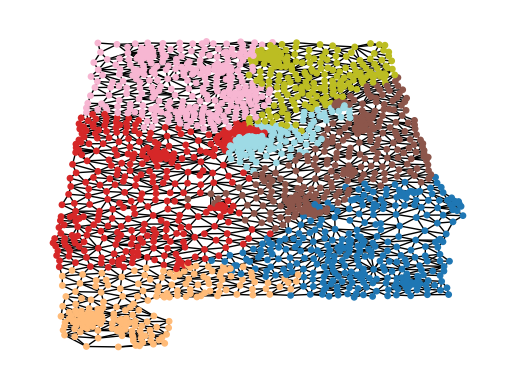

In [ ]:

cd_dict =  recursive_tree_part(graph,range(7),ideal_population,'population', epsilon = 0.02)

tree_partition = GeographicPartition(graph,cd_dict,my_updaters)

plt.plot(figsize=[4,10])
nx.draw(graph, pos = {x:(graph.nodes()[x]['C_X'],graph.nodes()[x]['C_Y']) for x in graph.nodes()},node_color=[cd_dict[x] for x in graph.nodes()],
        cmap='tab20',node_size=15)


If the tree plan satisfies your constraints, you can just use it as a starting point for the Markov chain. If it doesn't (say because it splits too many counties), then you may need to run a smaller initial Markov chain to get it to conform to your constraints. For example, the random tree plan above splits waaaaayyyy too many counties. So the cell below runs a short Markov chain until it only splits 9. 
    
    

In [ ]:
print(f"The initial tree seed splits {tree_partition['county_splits']} counties.")
    
county_proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.02,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":1},
    method = partial(bipartition_tree,max_attempts= 10000,  warn_attempts = 1000,  allow_pair_reselection = True)
)

second_recom_chain = MarkovChain(
    proposal=county_proposal,
    constraints=[],
    accept=accept.always_accept,
    initial_state=tree_partition,
    total_steps=1000
)

temp = 0
for part in second_recom_chain:
    temp +=1
    if temp %10 == 0:
        print(temp)
        
    if part['county_splits'] < 10:
        break    

new_starting_seed = GeographicPartition(graph, dict(part.assignment), my_updaters)

print(f"The new tree seed splits {new_starting_seed['county_splits']} counties.")


The initial tree seed splits 28 counties.
10
20
The new tree seed splits 9 counties.


The cell below sets up the proposal and Markov chain, including defining some constraints. This is probably what you'll want to modify the most!

In [ ]:


county_proposal = partial(
    recom,
    pop_col="population",
    pop_target=ideal_population,
    epsilon=0.01,
    node_repeats=2,
    region_surcharge = {"COUNTYFP":1},
    method = partial(bipartition_tree,max_attempts= 10000,  warn_attempts = 1000,  allow_pair_reselection = True)
)

def pp_constraint(partition): 

    return sum([1/x for x in polsby_popper(partition).values()])/7 > 4


def county_constraint(partition):

    return partition['county_splits'] < 11

def competitiveness_constraint(partition):

    return sum([abs(x-.5)<.05 for x in partition['PRE'].percents("Democratic")]) > 0


The cell below actually runs the Markov chain. The toy setup does 100 steps writing to file every 10 but you can (should) tweak that based on your hardware. If you prefer to have it write the files to separate subfolders, you can edit the directories in the filenames. 

In [ ]:

def run_markov_chain(proposal_function, constraint_choices, file_name, accept_function=accept.always_accept, seed=new_starting_seed, num_steps=100_000):

    second_recom_chain = MarkovChain(
        proposal=proposal_function,
        constraints=constraint_choices,
        accept=accept_function,
        initial_state=seed,
        total_steps=num_steps
    )

    cs = []
    mms = []
    egs = []
    pbs =[]
    dvp = []
    pps = []
    bvp = []
    mbvp = []
    wins = []
    cds = []

    #i added this
    opp_scores = []
    coal_scores = []
    prop_opp_scores = []
    prop_coal_scores = []
    #end of what i added

    temp = 0

    for part in second_recom_chain:

        temp += 1

        if temp %10 == 0:
        
            print("Step Number", temp)
            ad = dict(part.assignment)

            with open(f"{file_name}_{temp}.json", "w") as file:
                json.dump(ad, file)


            plt.figure(figsize=(4,10))
            nx.draw(graph, pos = {x:(graph.nodes()[x]['C_X'],graph.nodes()[x]['C_Y']) for x in graph.nodes()},node_color=[ad[x] for x in graph.nodes()],
                cmap='tab20b',node_size=15)
            plt.savefig(f'./network_plot_{temp}.png')
            plt.close()
    
            df['current'] = df["PRECINCTID"].map(ad)
            df.plot(column='current',cmap='tab20b')
            plt.axis('off')
            plt.savefig(f'./df_plot_{temp}.png')
            plt.close()


            ndf = pd.DataFrame({"CountySplits":cs, "MM":mms, 'EG':egs,'PB':pbs,'DWins':wins,'PP':pps,'Comp45-55':cds})

            ndf.to_csv(f"./{file_name}chain_outputs_{temp}.csv")
        
            with open(f"./{file_name}_DemPercs_{temp}.csv", "w") as tf1:
                writer = csv.writer(tf1, lineterminator="\n")
                writer.writerows(dvp)
        
        
            with open(f"./{file_name}_BlackPercs_{temp}.csv", "w") as tf1:
                writer = csv.writer(tf1, lineterminator="\n")
                writer.writerows(bvp)

            cs = []
            mms = []
            egs = []
            pbs =[]
            dvp = []
            pps = []
            bvp = []
            mbvp = []
            wins = []
            cds = []

            #I added thisisss
            opp_scores = []
            coal_scores = []
            prop_opp_scores = []
            prop_coal_scores = []
            #end of stuff added
    
        cs.append(part['county_splits'])
        mms.append(mean_median(part['PRE']))
        egs.append(efficiency_gap(part['PRE']))
        pbs.append(partisan_bias(part['PRE']))
        dvp.append(sorted(part['PRE'].percents("Democratic")))
        pps.append(sum([1/x for x in polsby_popper(part).values()])/7)
        bvp.append(sorted(part['NH_BLACK'].percents("NH_BLACK")))
        mbvp.append(max(bvp[-1]))
        wins.append(part['PRE'].wins("Democratic"))
        cds.append(sum([abs(x-.5)<.05 for x in part['PRE'].percents("Democratic")]))


    ##i added this for mmd
        demos_by_district = get_demos_by_district(part)
        minority_scores = calc_minority_metrics(statewide_demos, demos_by_district)

        opp_scores.append(minority_scores["opportunity_districts"])
        coal_scores.append(minority_scores["coalition_districts"])
        prop_opp_scores.append(minority_scores["proportional_opportunities"])
        prop_coal_scores.append(minority_scores["proportional_coalitions"])

    #end of stuff addedd

run_markov_chain(county_proposal, [pp_constraint, county_constraint, competitiveness_constraint], "Testing_01", num_steps=100)
print("First chain done")
run_markov_chain(county_proposal, [pp_constraint, county_constraint, competitiveness_constraint], "Testing_02", num_steps=100)
print("Second chain done")



Step Number 10
Step Number 20
Step Number 30
Step Number 40
Step Number 50
Step Number 60
Step Number 70
Step Number 80
Step Number 90
Step Number 100
